In [18]:
import numpy as np
import cv2
from skimage.morphology import remove_small_objects, dilation, skeletonize, skeletonize_3d, medial_axis, binary_closing
from skimage.segmentation import clear_border
from skimage.filters import unsharp_mask, threshold_triangle, difference_of_gaussians
from skimage.graph import shortest_path, route_through_array
import matplotlib.pyplot as plt

In [19]:
skeleton = cv2.imread('/home/jani/Documents/pics/depth_skel1.jpg')

skeleton = cv2.cvtColor(skeleton, cv2.COLOR_BGR2GRAY)

In [20]:
pixels = np.argwhere(skeleton == 255)

pixels = np.flip(pixels)

copy_pix = pixels

print(copy_pix)

[[252 198]
 [252 197]
 [253 196]
 [253 195]
 [254 194]
 [255 192]
 [256 191]
 [257 190]
 [258 189]
 [259 188]
 [260 187]
 [263 185]
 [262 185]
 [266 184]
 [264 184]
 [269 181]
 [270 180]
 [271 179]
 [272 178]
 [272 176]
 [273 174]
 [273 173]
 [274 172]
 [275 170]
 [275 169]
 [275 168]
 [276 167]
 [276 166]
 [276 165]
 [276 164]
 [276 163]
 [276 162]
 [276 161]
 [276 160]
 [276 159]
 [276 158]
 [276 157]
 [276 156]
 [276 155]
 [276 154]
 [276 153]
 [276 152]
 [276 151]
 [276 149]
 [276 148]
 [276 147]
 [277 145]
 [277 144]
 [277 143]
 [278 142]
 [278 141]
 [278 140]
 [278 139]
 [279 138]
 [279 137]
 [279 135]
 [280 133]
 [280 132]
 [280 131]
 [280 129]
 [280 128]
 [280 127]
 [280 125]
 [279 124]
 [165 124]
 [161 124]
 [279 123]
 [163 123]
 [158 123]
 [278 122]
 [153 122]
 [152 122]
 [151 122]
 [278 121]
 [150 121]
 [ 98 121]
 [ 97 121]
 [278 120]
 [149 120]
 [ 99 120]
 [278 119]
 [148 119]
 [101 119]
 [104 118]
 [103 118]
 [102 118]
 [145 117]
 [107 117]
 [106 117]
 [144 116]
 [108 116]

In [21]:
initial_pos = pixels[0] #extract the center of the base marker and get initial position    
row_index, = np.where(np.all(copy_pix == [initial_pos], axis=1))
copy_pix = np.delete(copy_pix, row_index, axis=0)
print(copy_pix[0])
point_len = len(copy_pix)    
ordered = initial_pos
print(ordered)

[252 197]
[252 198]


In [22]:
while len(copy_pix)>0:
    distances = np.sqrt((copy_pix[:,0] - initial_pos[0]) ** 2 + (copy_pix[:,1] - initial_pos[1]) ** 2)
#     print(distances)
    nearest_index = np.argmin(distances)
    print("Point {} matched with {}".format(initial_pos, copy_pix[nearest_index]))
    print("Nearest index: {}".format(nearest_index))
    initial_pos = copy_pix[nearest_index] #(target[0], target[1])
    print("Initial Pose", initial_pos)
    copy_pix = np.delete(copy_pix, nearest_index, axis=0)
#     print(copy_pix[0])
    point_len = len(copy_pix)
    ordered = np.append(ordered, [initial_pos])
print(ordered)


Point [252 198] matched with [252 197]
Nearest index: 0
Initial Pose [252 197]
Point [252 197] matched with [253 196]
Nearest index: 0
Initial Pose [253 196]
Point [253 196] matched with [253 195]
Nearest index: 0
Initial Pose [253 195]
Point [253 195] matched with [254 194]
Nearest index: 0
Initial Pose [254 194]
Point [254 194] matched with [255 192]
Nearest index: 0
Initial Pose [255 192]
Point [255 192] matched with [256 191]
Nearest index: 0
Initial Pose [256 191]
Point [256 191] matched with [257 190]
Nearest index: 0
Initial Pose [257 190]
Point [257 190] matched with [258 189]
Nearest index: 0
Initial Pose [258 189]
Point [258 189] matched with [259 188]
Nearest index: 0
Initial Pose [259 188]
Point [259 188] matched with [260 187]
Nearest index: 0
Initial Pose [260 187]
Point [260 187] matched with [262 185]
Nearest index: 1
Initial Pose [262 185]
Point [262 185] matched with [263 185]
Nearest index: 0
Initial Pose [263 185]
Point [263 185] matched with [264 184]
Nearest index

In [23]:
ordered = np.reshape(ordered, (-1, 2))

x = ordered[:, 1]
y = ordered[:, 0]

print(len(ordered))


247


/tmp/ipykernel_80322/4092672185.py:5: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


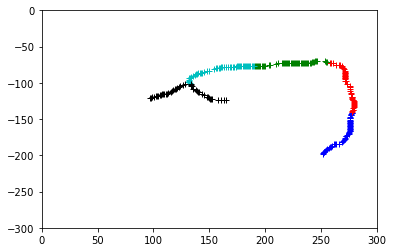

In [24]:
fig = None
if fig == None:
    fig = plt.figure()
    ax = fig.add_subplot(111)
    fig.show()
    fig.canvas.draw()
ax.clear()
ax.set_xlim([0, 300])
ax.set_ylim([-300, 0])
# ax.set_ylim([0, 300])

ax.plot(y[0:51], -x[0:51], 'b+', label='Data')
ax.plot(y[51:101], -x[51:101], 'r+', label='Data')
ax.plot(y[101:151], -x[101:151], 'g+', label='Data')
ax.plot(y[151:201], -x[151:201], 'c+', label='Data')
ax.plot(y[201:251], -x[201:251], 'k+', label='Data')
ax.plot(y[251:301], -x[251:301], 'bo', label='Data')
ax.plot(y[301:-1], -x[301:-1], 'ro', label='Data')

In [25]:
(rows,cols) = np.nonzero(skeleton)
print(rows)
print(cols)

[ 64  64  64 ... 199 199 199]
[240 242 243 ... 249 251 253]


In [26]:
skel_coords = []
intersection = []

for (r,c) in zip(rows,cols):

    # Extract an 8-connected neighbourhood
    (col_neigh,row_neigh) = np.meshgrid(np.array([c-1,c,c+1]), np.array([r-1,r,r+1]))
    # Cast to int to index into image
#     col_neigh = np.array([c-1, c, c+1])
    col_neigh = col_neigh.astype('int')
    print(col_neigh)
#     row_neigh = np.array([r-1,r,r+1])
    row_neigh = row_neigh.astype('int')
    print(row_neigh)

    # Convert into a single 1D array and check for non-zero locations
    print(skeleton[row_neigh,col_neigh].ravel())
    pix_nbhood = skeleton[row_neigh,col_neigh].ravel() != 0 
    print(pix_nbhood)
    print(np.sum(pix_nbhood))

    # If the number of non-zero locations equals 2, add this to 
    # our list of co-ordinates for end points
    if np.sum(pix_nbhood) < 3:
#         print(np.sum(pix_nbhood))
        skel_coords.append((c,r))
    # our list of co-ordinates for intersection points
    elif np.sum(pix_nbhood) == 4:
#         print(np.sum(pix_nbhood))
        intersection.append((c,r))

[[239 240 241]
 [239 240 241]
 [239 240 241]]
[[63 63 63]
 [64 64 64]
 [65 65 65]]
[0 0 0 0 1 0 0 2 0]
[False False False False  True False False  True False]
2
[[241 242 243]
 [241 242 243]
 [241 242 243]]
[[63 63 63]
 [64 64 64]
 [65 65 65]]
[0 0 0 0 1 2 0 0 0]
[False False False False  True  True False False False]
2
[[242 243 244]
 [242 243 244]
 [242 243 244]]
[[63 63 63]
 [64 64 64]
 [65 65 65]]
[0 0 0 1 2 0 0 0 2]
[False False False  True  True False False False  True]
3
[[244 245 246]
 [244 245 246]
 [244 245 246]]
[[63 63 63]
 [64 64 64]
 [65 65 65]]
[0 0 0 0 2 0 2 2 1]
[False False False False  True False  True  True  True]
4
[[249 250 251]
 [249 250 251]
 [249 250 251]]
[[63 63 63]
 [64 64 64]
 [65 65 65]]
[0 0 0 0 2 1 2 0 1]
[False False False False  True  True  True False  True]
4
[[250 251 252]
 [250 251 252]
 [250 251 252]]
[[63 63 63]
 [64 64 64]
 [65 65 65]]
[0 0 0 2 1 0 0 1 0]
[False False False  True  True False False  True False]
3
[[256 257 258]
 [256 257 258]
 [25

 [81 81 81]]
[0 0 0 2 2 0 0 0 0]
[False False False  True  True False False False False]
2
[[140 141 142]
 [140 141 142]
 [140 141 142]]
[[79 79 79]
 [80 80 80]
 [81 81 81]]
[0 0 0 0 1 0 0 1 1]
[False False False False  True False False  True  True]
3
[[143 144 145]
 [143 144 145]
 [143 144 145]]
[[79 79 79]
 [80 80 80]
 [81 81 81]]
[0 0 0 0 1 0 0 0 3]
[False False False False  True False False False  True]
2
[[145 146 147]
 [145 146 147]
 [145 146 147]]
[[79 79 79]
 [80 80 80]
 [81 81 81]]
[0 0 0 0 3 0 3 0 0]
[False False False False  True False  True False False]
2
[[148 149 150]
 [148 149 150]
 [148 149 150]]
[[79 79 79]
 [80 80 80]
 [81 81 81]]
[0 0 0 0 2 0 1 0 0]
[False False False False  True False  True False False]
2
[[150 151 152]
 [150 151 152]
 [150 151 152]]
[[79 79 79]
 [80 80 80]
 [81 81 81]]
[0 0 1 0 1 0 0 0 1]
[False False  True False  True False False False  True]
3
[[152 153 154]
 [152 153 154]
 [152 153 154]]
[[79 79 79]
 [80 80 80]
 [81 81 81]]
[  1   0   0   0   2 

 [277 278 279]]
[[106 106 106]
 [107 107 107]
 [108 108 108]]
[0 0 0 1 1 2 0 2 0]
[False False False  True  True  True False  True False]
4
[[278 279 280]
 [278 279 280]
 [278 279 280]]
[[106 106 106]
 [107 107 107]
 [108 108 108]]
[0 0 0 1 2 0 2 0 0]
[False False False  True  True False  True False False]
3
[[111 112 113]
 [111 112 113]
 [111 112 113]]
[[107 107 107]
 [108 108 108]
 [109 109 109]]
[0 0 3 0 1 0 0 1 0]
[False False  True False  True False False  True False]
3
[[113 114 115]
 [113 114 115]
 [113 114 115]]
[[107 107 107]
 [108 108 108]
 [109 109 109]]
[3 0 1 0 1 0 0 0 3]
[ True False  True False  True False False False  True]
4
[[116 117 118]
 [116 117 118]
 [116 117 118]]
[[107 107 107]
 [108 108 108]
 [109 109 109]]
[0 2 0 0 4 0 2 0 2]
[False  True False False  True False  True False  True]
4
[[118 119 120]
 [118 119 120]
 [118 119 120]]
[[107 107 107]
 [108 108 108]
 [109 109 109]]
[  0   0   0   0   2 255   2 255   1]
[False False False False  True  True  True  True  

 [127 127 127]]
[0 0 0 1 1 0 3 0 0]
[False False False  True  True False  True False False]
3
[[151 152 153]
 [151 152 153]
 [151 152 153]]
[[125 125 125]
 [126 126 126]
 [127 127 127]]
[0 0 3 0 1 0 0 0 0]
[False False  True False  True False False False False]
2
[[154 155 156]
 [154 155 156]
 [154 155 156]]
[[125 125 125]
 [126 126 126]
 [127 127 127]]
[0 0 1 0 2 0 1 0 1]
[False False  True False  True False  True False  True]
4
[[162 163 164]
 [162 163 164]
 [162 163 164]]
[[125 125 125]
 [126 126 126]
 [127 127 127]]
[1 0 3 0 3 0 0 0 0]
[ True False  True False  True False False False False]
3
[[164 165 166]
 [164 165 166]
 [164 165 166]]
[[125 125 125]
 [126 126 126]
 [127 127 127]]
[3 2 0 0 1 0 0 0 2]
[ True  True False False  True False False False  True]
4
[[166 167 168]
 [166 167 168]
 [166 167 168]]
[[125 125 125]
 [126 126 126]
 [127 127 127]]
[0 0 0 0 1 0 2 0 0]
[False False False False  True False  True False False]
2
[[274 275 276]
 [274 275 276]
 [274 275 276]]
[[125 125 

In [27]:
print(skel_coords)



[(240, 64), (242, 64), (257, 64), (263, 64), (241, 66), (243, 66), (263, 67), (240, 70), (152, 72), (158, 72), (160, 72), (166, 72), (265, 72), (267, 72), (271, 72), (164, 73), (175, 73), (256, 73), (269, 73), (200, 74), (267, 74), (152, 75), (172, 75), (256, 75), (168, 76), (170, 76), (240, 76), (215, 77), (241, 78), (263, 78), (264, 78), (266, 78), (201, 79), (204, 79), (207, 79), (214, 79), (240, 79), (243, 79), (256, 79), (138, 80), (139, 80), (144, 80), (146, 80), (149, 80), (273, 80), (275, 80), (277, 80), (136, 81), (159, 81), (275, 82), (159, 83), (279, 84), (149, 86), (151, 86), (152, 86), (159, 87), (264, 87), (267, 87), (279, 87), (131, 88), (141, 89), (143, 89), (128, 90), (141, 91), (143, 91), (141, 95), (120, 96), (126, 96), (134, 97), (277, 97), (279, 98), (120, 99), (278, 102), (120, 103), (272, 103), (118, 104), (138, 104), (143, 104), (120, 105), (278, 105), (279, 105), (118, 106), (272, 106), (273, 106), (115, 107), (143, 107), (127, 108), (272, 108), (273, 109), (12

In [28]:
print(intersection)

[(245, 64), (250, 64), (247, 65), (249, 65), (248, 66), (252, 66), (257, 66), (258, 66), (246, 67), (259, 67), (243, 68), (244, 68), (258, 68), (244, 69), (254, 69), (242, 70), (246, 70), (257, 70), (261, 70), (262, 70), (242, 71), (244, 71), (255, 71), (169, 72), (170, 72), (207, 72), (213, 72), (244, 72), (247, 72), (262, 72), (171, 73), (202, 73), (206, 73), (209, 73), (239, 73), (263, 73), (270, 73), (157, 74), (158, 74), (159, 74), (160, 74), (206, 74), (246, 74), (258, 74), (156, 75), (211, 75), (214, 75), (242, 75), (245, 75), (257, 75), (259, 75), (157, 76), (159, 76), (160, 76), (175, 76), (200, 76), (202, 76), (213, 76), (214, 76), (241, 76), (242, 76), (244, 76), (261, 76), (262, 76), (264, 76), (266, 76), (176, 77), (199, 77), (200, 77), (201, 77), (206, 77), (212, 77), (243, 77), (245, 77), (258, 77), (153, 78), (154, 78), (158, 78), (162, 78), (172, 78), (209, 78), (210, 78), (213, 78), (246, 78), (256, 78), (258, 78), (152, 79), (160, 79), (165, 79), (168, 79), (170, 79)